In [1]:

import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle, Patch


In [2]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
sims=xr.open_dataset("../output/timeseries_from1D.nc")
temp=xr.open_dataset("../output/timeseries_from2D.nc")
leg24=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/regions_area_paleogris.nc")
lec_A=pd.read_csv("/p/projects/megarun/luciagu/data/lecavalier2014/lecavalier2014_hhuy3_area.csv")
lec_V=pd.read_csv("/p/projects/megarun/luciagu/data/lecavalier2014/lecavalier2014_Huy3model.csv") #10^15 m3
conv_km3_sle= (1e-3) / 394.7 #[m/mm] / [km^3 to raise ocean by 1mm] => m sle, see https://sealevel.info/conversion_factors.html
conv = 1e15*1e-9*conv_km3_sle # from 10^15 m3 to m sea level equivalent
leg_A=pd.read_csv("/p/projects/megarun/luciagu/data/leger2025/leger2025_area.csv")
leg_V=pd.read_csv("/p/projects/megarun/luciagu/data/leger2025/leger2025_vol.csv")
lau=xr.open_dataset("/p/projects/megarun/luciagu/data/lauritzen2025/ex_366_highres.nc")
lau_b=xr.open_dataset("/p/projects/megarun/luciagu/data/lauritzen2025/Greenland_Basins_PS_v1.4.2_nnextrapolated_10.0km.nc")
mask=xr.where((lau.cell_grounded_fraction==1)&(lau_b.mask!=0),1,0)
lau_A=mask.sum(dim=["y","x"])*10**2*1e-6
lau_time=lau.time.dt.year*1e-3
mask=xr.where((lau.cell_grounded_fraction==1)&(lau_b.mask!=0),1,0)
lau_V=(lau.thk*mask).sum(dim=["y","x"])*1e-3*10**2*conv_km3_sle

pmist=xr.open_dataset("../../FesmData/Gowan2021_PaleoMIST1.0/output/North_America_paleomist.nc",engine='netcdf4')
mask = xr.where((pmist.x>4.55*1e6)&(pmist.x<6.6*1e6)&(pmist.y>-0.6*pmist.x+7.1*1e6)&(pmist.thickness>0),1,0)
pmist_time=-pmist.time*1e-3
pmist_A=mask.sum(dim=["x","y"])*5000**2*1e-6*1e-6 # km²
pmist_V=(pmist.thickness*mask).sum(dim=["y","x"])*5000**2*1e-9*conv_km3_sle

n_best=2572
best=sims.sel(sim=n_best)
tab=sims.sel(sim=305)

# Observations
A_obs=1.7
V_obs=7.4


/tmp/ipykernel_2851251/1927959699.py:13: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  lau=xr.open_dataset("/p/projects/megarun/luciagu/data/lauritzen2025/ex_366_highres.nc")


/tmp/ipykernel_2851251/2084153902.py:35: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = Rectangle((-19, 2.94), 3, 0.2, color='red', edgecolor="black", alpha=0.4,


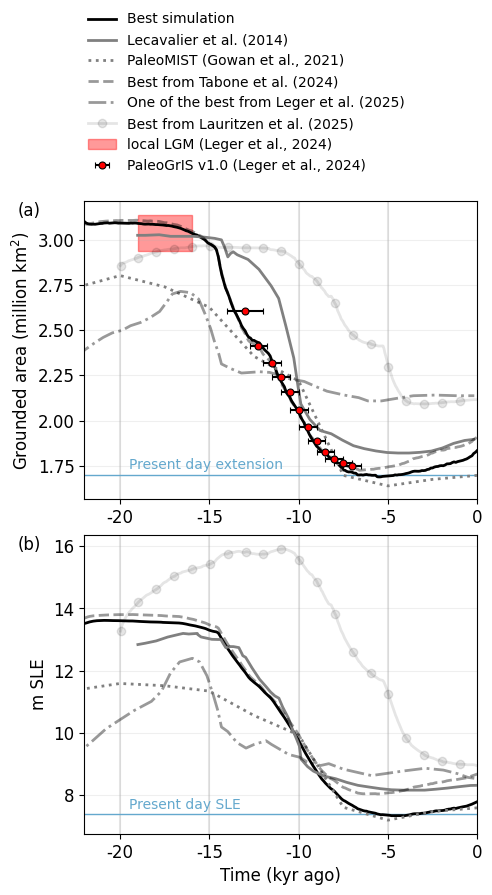

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(5, 9))
ax1, ax2 = axs

# 1. SIMULATIONS 
alph=0.4
ax1.plot(best.time/1e3, best.A_ice_g, color='black', linewidth=2, zorder=3, 
         label=f'Best simulation')
ax2.plot(best.time/1e3, best.V_sle, color='black', linewidth=2, zorder=3)

ax1.plot(lec_A.time.values, lec_A.A_ice.values, color='grey', alpha=1,linestyle="solid", linewidth=2, zorder=3, 
         label="Lecavalier et al. (2014)")
ax2.plot(lec_V.time.values, lec_V.V_ice.values*conv, color='grey', alpha=1,linestyle="solid", linewidth=2, zorder=3)

ax1.plot(pmist_time, pmist_A, color='grey', alpha=1,linestyle="dotted", linewidth=2, zorder=3, 
         label="PaleoMIST (Gowan et al., 2021)")
ax2.plot(pmist_time, pmist_V, color='grey', alpha=1,linestyle="dotted", linewidth=2, zorder=3)

ax1.plot(tab.time/1e3, tab.A_ice_g, color='black', alpha=alph,linestyle="dashed", linewidth=2, zorder=3, 
         label="Best from Tabone et al. (2024)")
ax2.plot(tab.time/1e3, tab.V_sle, color='black', alpha=alph,linestyle="dashed", linewidth=2, zorder=3)

ax1.plot(leg_A.values[:,0], leg_A.values[:,1], color='black', alpha=alph,linestyle="dashdot", linewidth=2, zorder=3, 
         label="One of the best from Leger et al. (2025)")
ax2.plot(leg_V.values[:,0], leg_V.values[:,1]+V_obs, color='black', alpha=alph,linestyle="dashdot", linewidth=2, zorder=3)

ax1.plot(lau_time, lau_A, color='black', alpha=alph-0.3,linestyle="-", marker='o',linewidth=2, zorder=3, 
         markevery=20,label="Best from Lauritzen et al. (2025)")
ax2.plot(lau_time, lau_V, color='black', alpha=alph-0.3,linestyle="-", marker='o',linewidth=2, zorder=3,
         markevery=20)


# 2. OBSERVATIONS
ax1.axhline(y=A_obs, color='#64A8CD', linestyle='-', alpha=1, linewidth=1, zorder=2)
ax2.axhline(y=V_obs, color='#64A8CD', linestyle='-', alpha=1, linewidth=1, zorder=2)
rect = Rectangle((-19, 2.94), 3, 0.2, color='red', edgecolor="black", alpha=0.4, 
                 label="local LGM (Leger et al., 2024)")
ax1.add_patch(rect)

ax1.errorbar(-leg24["time"][1:] * 1e-3, leg24.tot[1:], xerr=leg24.time_err[1:]*1e-3, fmt='o', ecolor='black',
             markersize=5, markerfacecolor='red', markeredgecolor='black', markeredgewidth=0.8,
             capsize=2, zorder=4, label="PaleoGrIS v1.0 (Leger et al., 2024)")
ax1.text(-19.5,A_obs+0.03,"Present day extension",color="#64A8CD",fontsize=10)
ax2.text(-19.5,V_obs+0.15,"Present day SLE",color="#64A8CD",fontsize=10)


# --- FORMATO ---
ax2.set_ylabel('m SLE')
ax1.set_ylabel(r'Grounded area (million km$^2$)') 
ax1.text(-0.17,0.95,"(a)",transform=ax1.transAxes)
ax2.text(-0.17,0.95,"(b)",transform=ax2.transAxes)

ax2.set_xlabel('Time (kyr ago)')
for i, ax in enumerate(axs):
    ax.grid(alpha=0.2, zorder=1)
    ax.set_xlim(-22, 0)
    for x_val in [-20, -15, -10, -5]:
        ax.axvline(x=x_val, color='black', linestyle='-', alpha=0.1, zorder=1)

# --- LEYENDA
handles, labels = ax1.get_legend_handles_labels()
leg = fig.legend(handles=handles, 
                 labels=labels,
                 loc='upper center', 
                 ncol=1, 
                 frameon=False,
                 fontsize='small')

plt.tight_layout()
plt.subplots_adjust(top=0.78)
plt.savefig(f"../figs_final/fig13_{n_best}_comparison_models.pdf", dpi=300)
# plt.close()